# Evaluating a trained KIND model

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot

### Load a trained KIND model

In [2]:
# --! load a trained KIND model --!

model = torch.load('../../models/baselines/tesla_kind.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=640, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=16, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=192, bias=True)
          (1): Identity()
        )
      )
    )
    (pre_me

### Analyze the stationary part of a KIND model

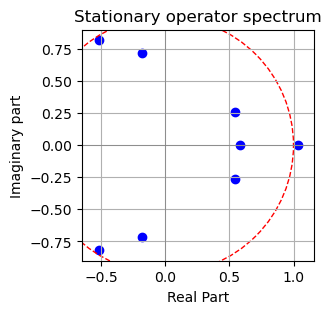

tensor([-0.5193+0.8187j, -0.5193-0.8187j, -0.1783+0.7167j, -0.1783-0.7167j,
         1.0323+0.0000j,  0.5419+0.2609j,  0.5419-0.2609j,  0.5844+0.0000j])


In [3]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

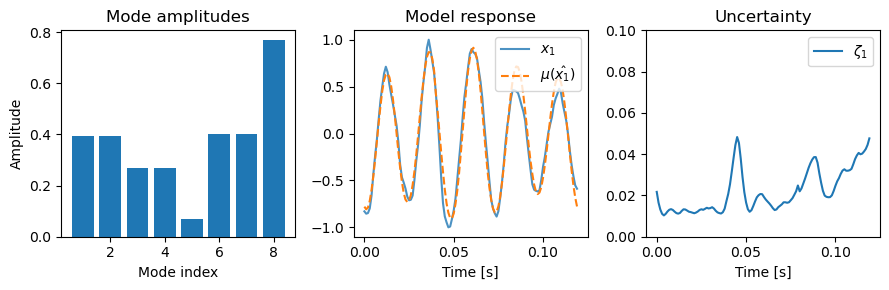

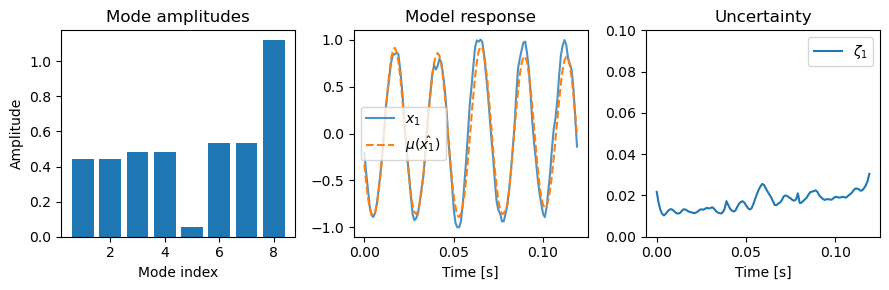

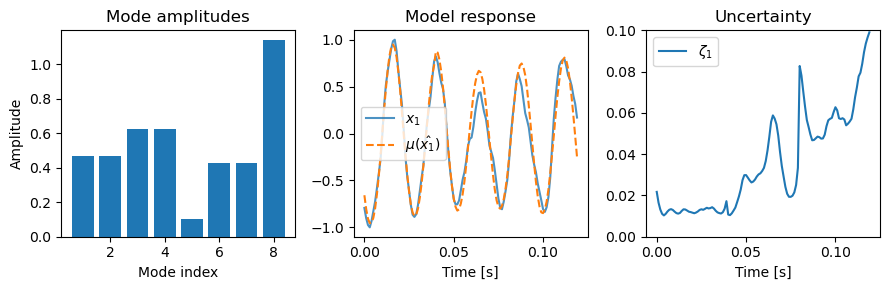

In [4]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/tesla_train_stat'
timeseries_nsample = 120

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### Evaluate KIND performance on test data

In [5]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/tesla_test'
timeseries_nsample = 250_000

mse_stat, mse_trans, mse_blend = utils_plot.plot_mse(model, datadir, timeseries_nsample, with_units=False)

test shape: (249880, 40, 1) (249880, 40, 1)
test shape: (249880, 40, 1) (249880, 40, 1)
Blend MSE : 0.084
Blend MAE : 0.216
Stat MSE : 0.214
Stat MAE : 0.349
Trans MSE : 0.086
Trans MAE : 0.216
Stat uncertainty : 0.23771600425243378
Trans uncertainty : 0.04844990000128746

inf >> forecasting results:

         mse      index      value
 -----------   --------   --------
  best blend     201191      0.001
 worst blend       6145      1.328
   avg blend         na      0.084
                                  
   best stat     201192      0.001
  worst stat       2012      2.082
    avg stat         na      0.214
                                  
  best trans     150515      0.001
 worst trans      57199      1.437
   avg trans         na      0.086

inf >> mean alpha is 0.26



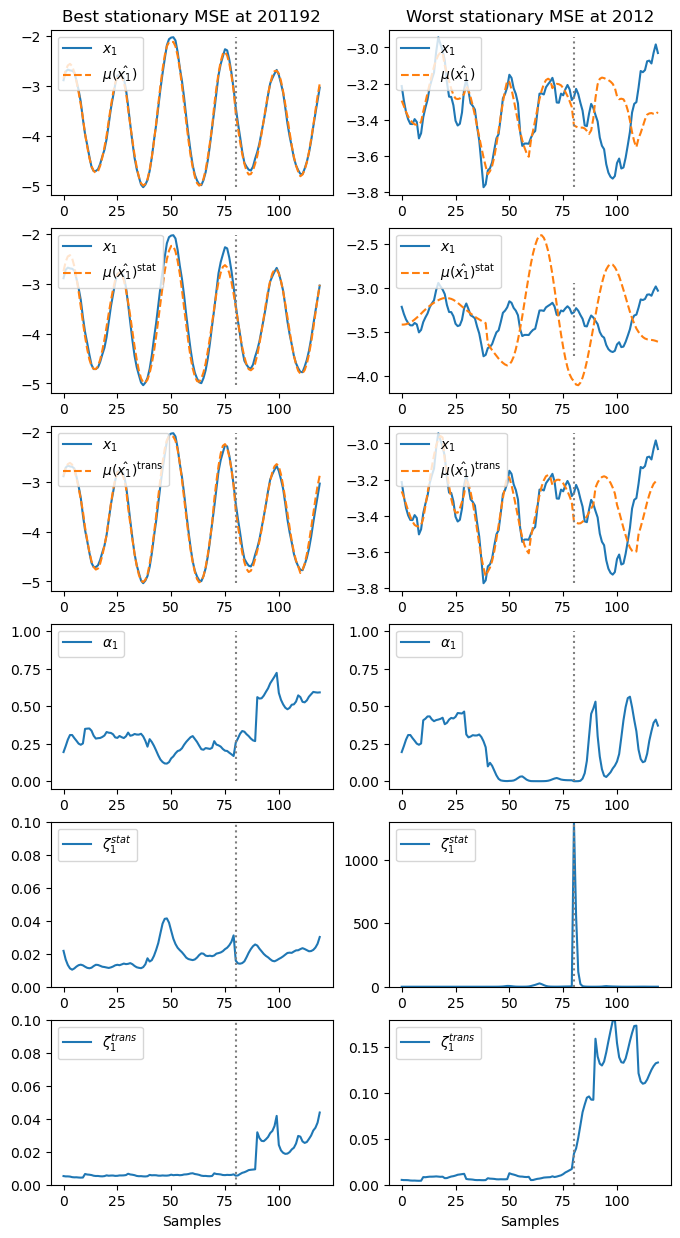

In [6]:
# --! plot the best and worst stationary performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_stat, mse_type='stationary',
    datasaved=True, savedir='../../savedata/baselines/tesla')

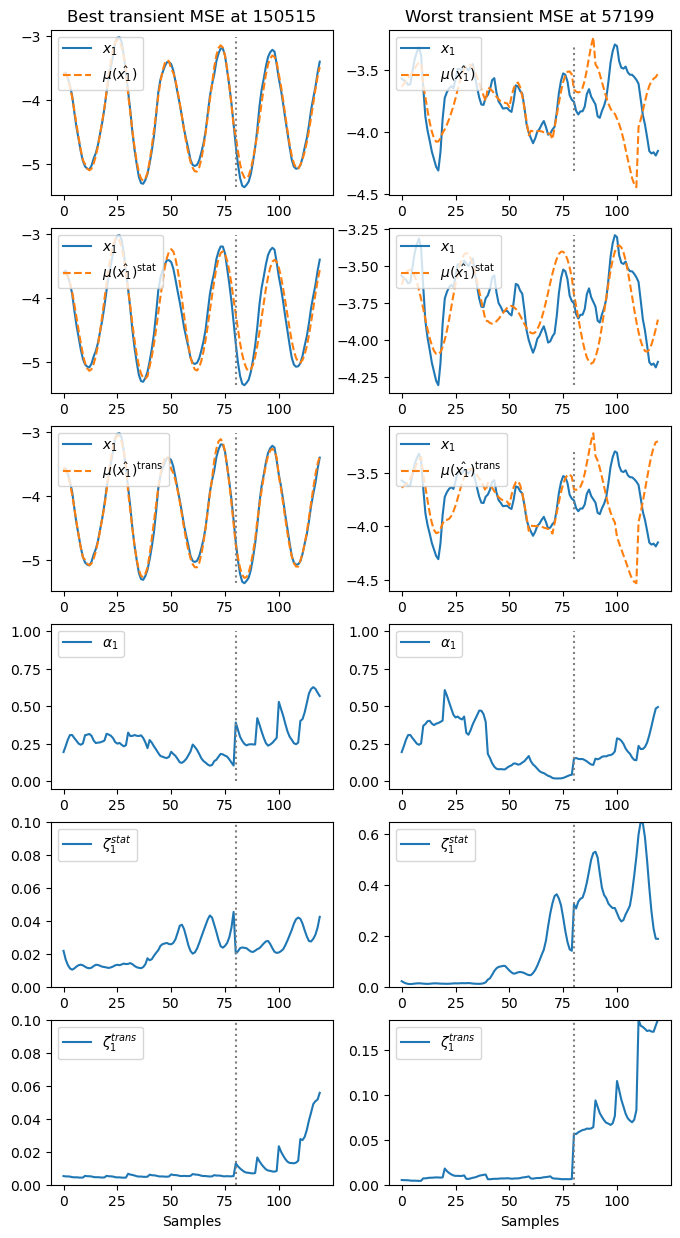

In [7]:
# --! plot the best and worst transient performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_trans, mse_type='transient',
    datasaved=True, savedir='../../savedata/baselines/tesla')

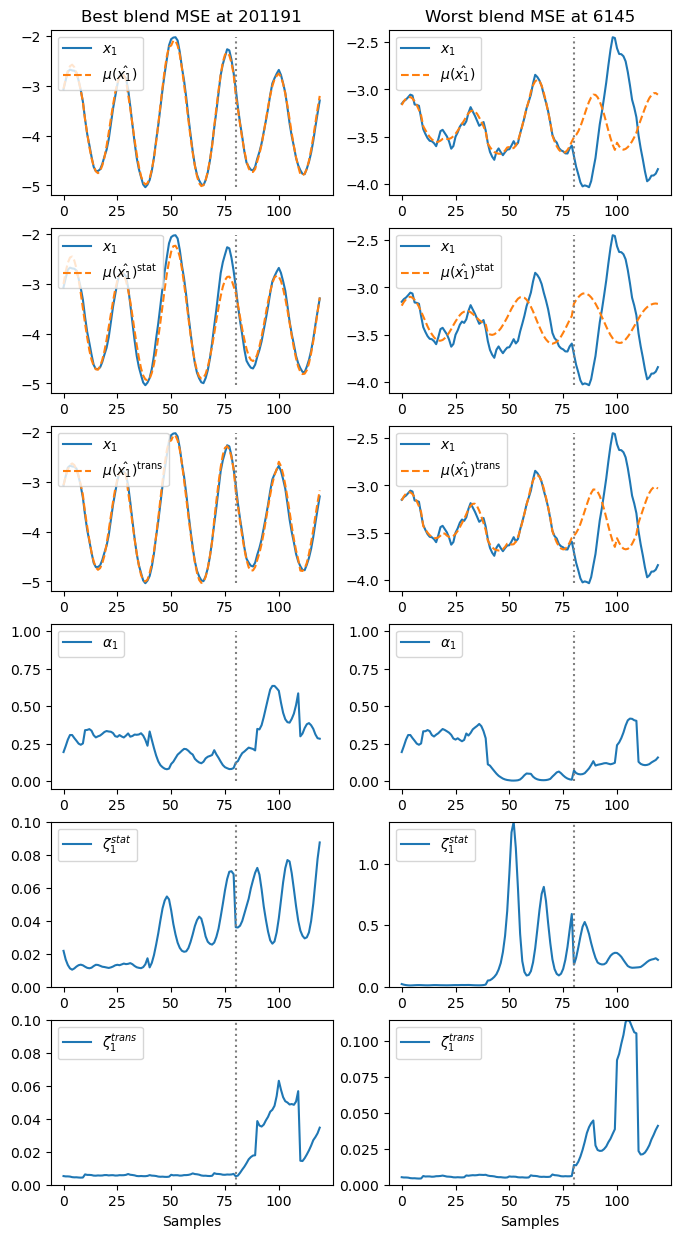

In [8]:
# --! plot the best and worst blending performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    datasaved=True, savedir='../../savedata/baselines/tesla')

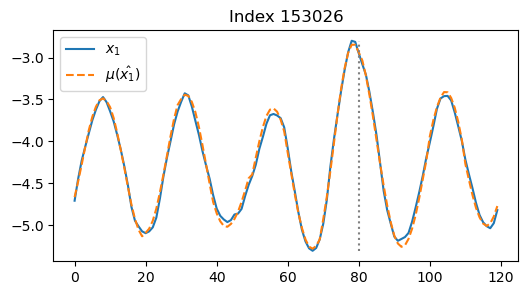

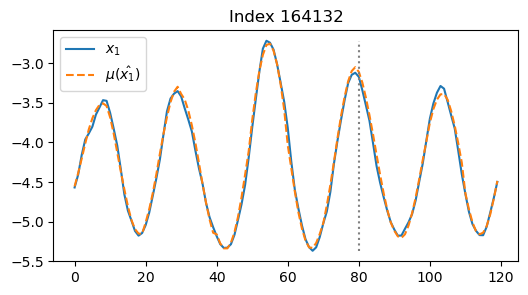

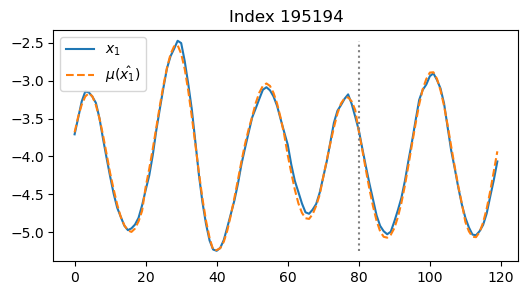

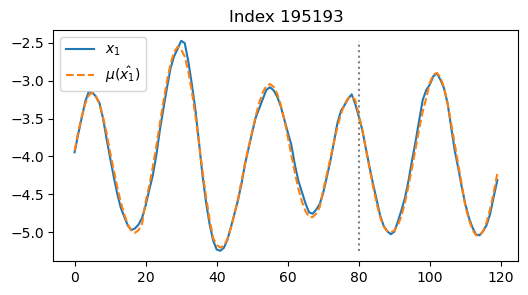

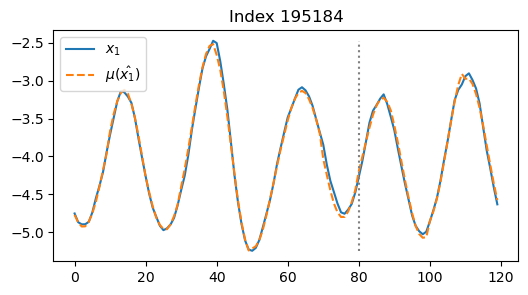

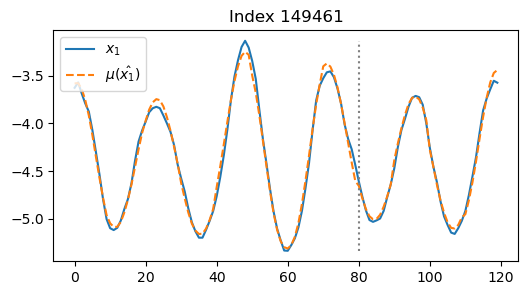

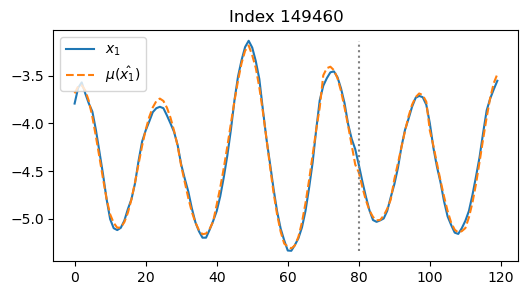

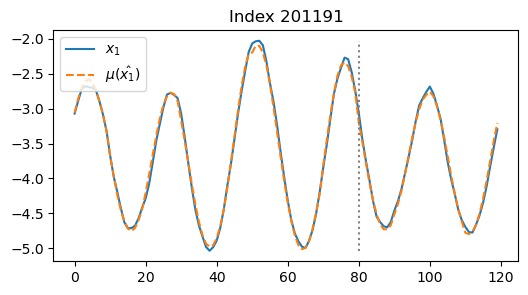

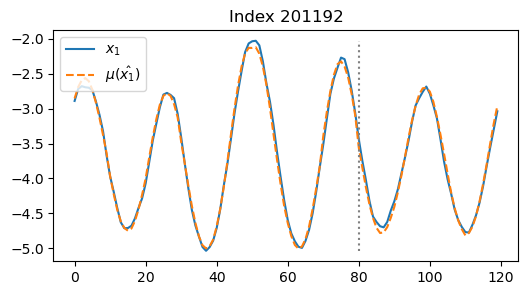

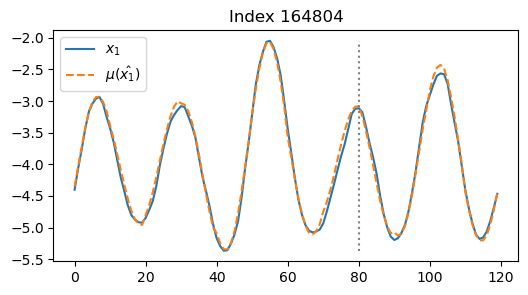

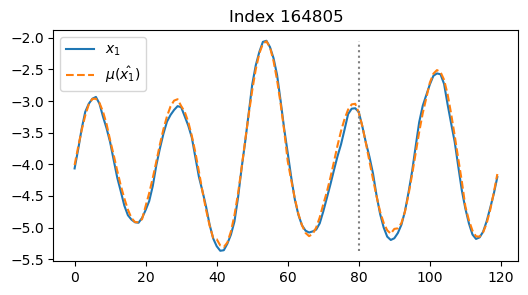

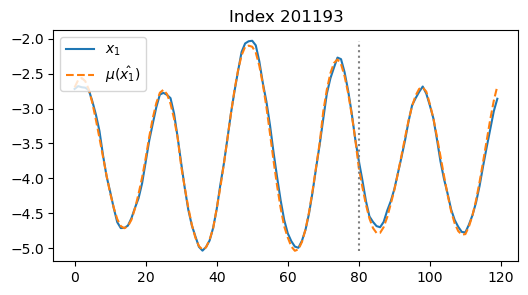

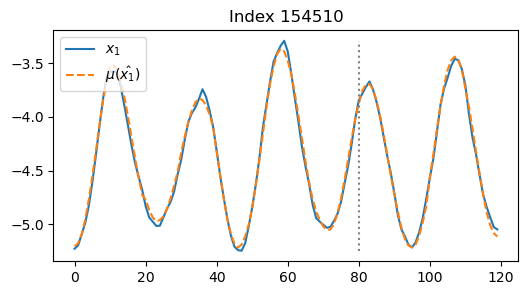

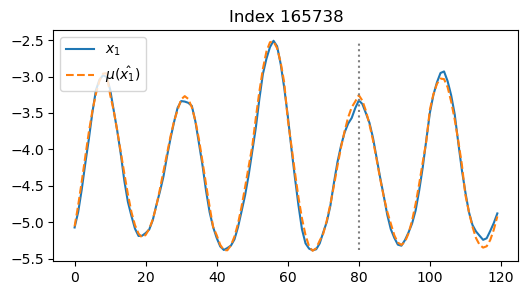

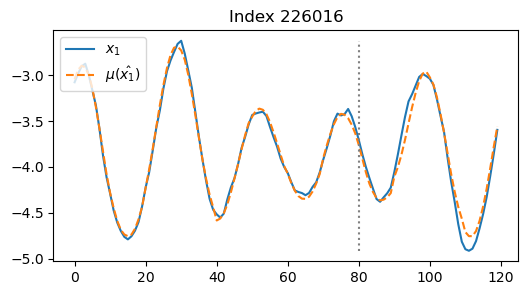

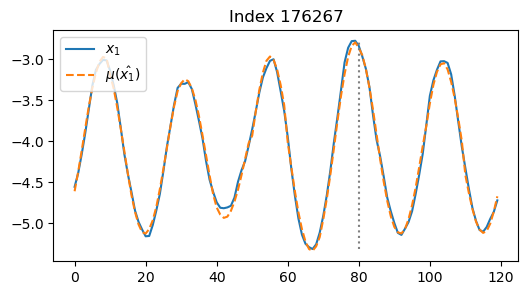

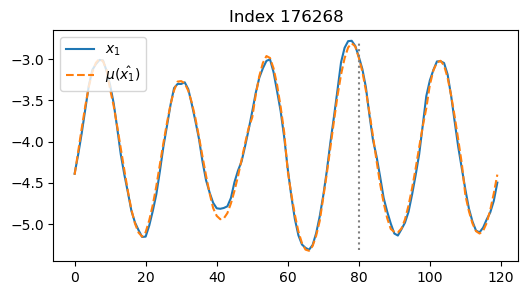

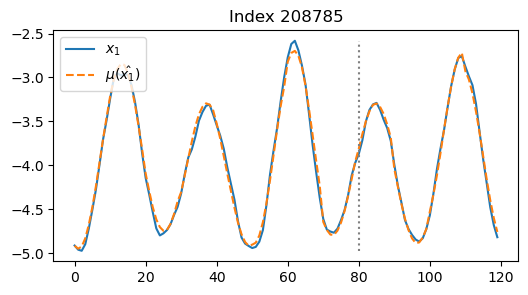

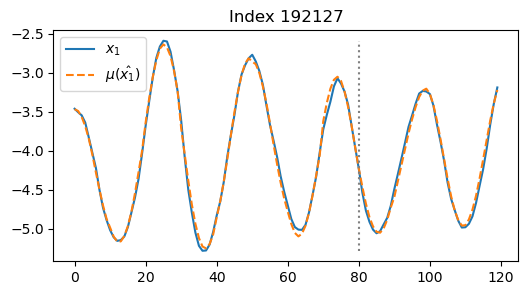

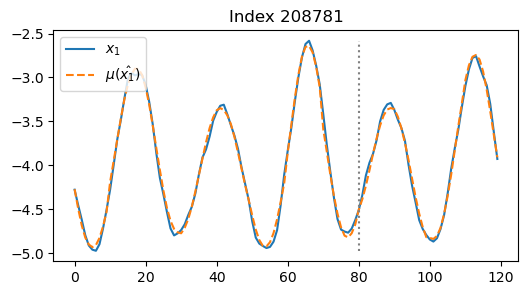

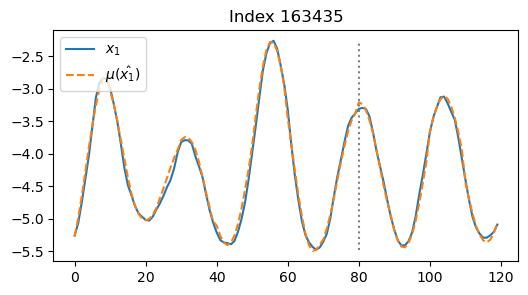

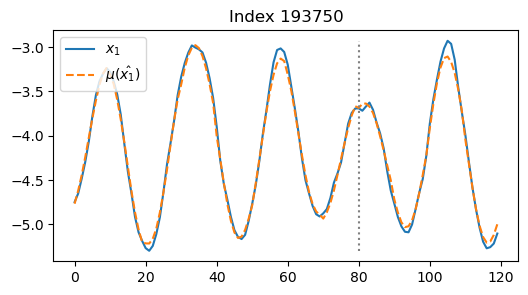

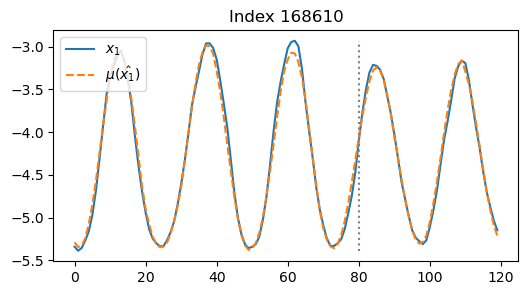

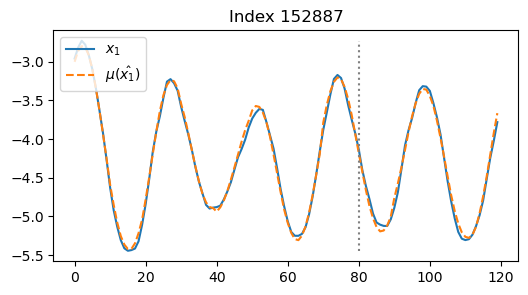

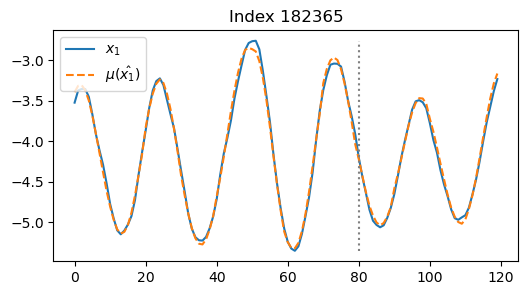

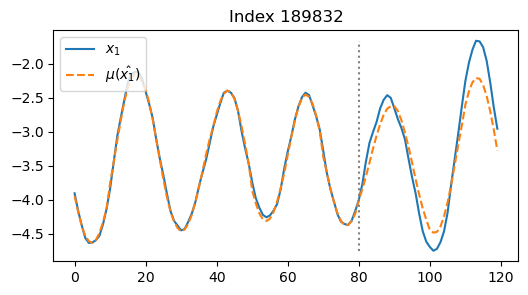

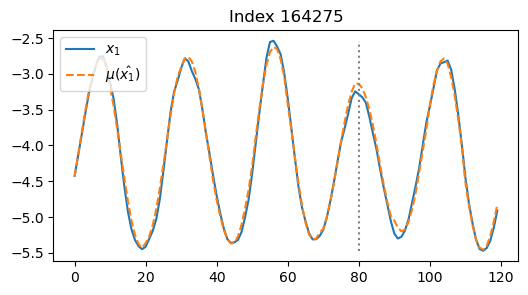

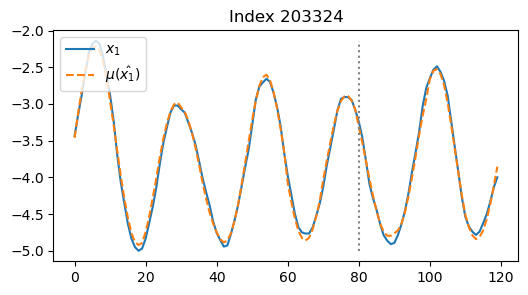

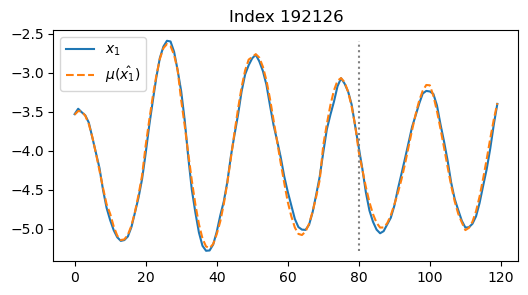

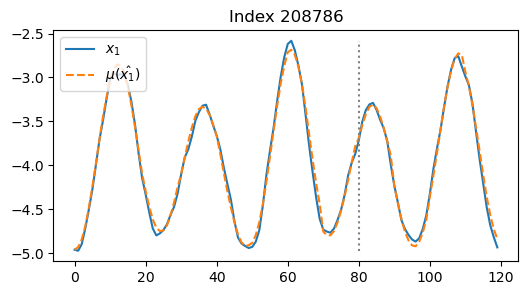

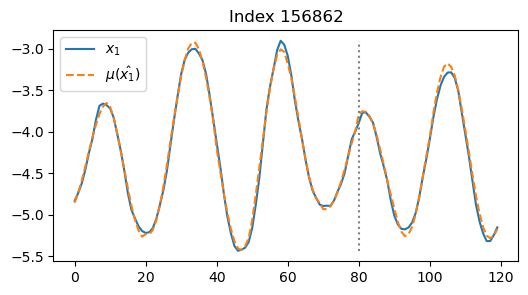

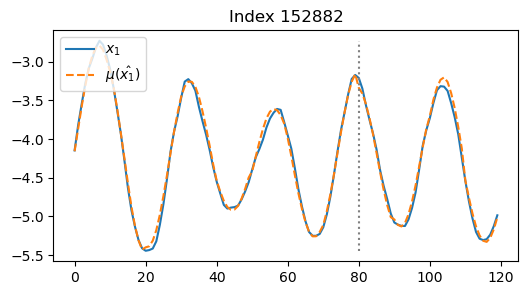

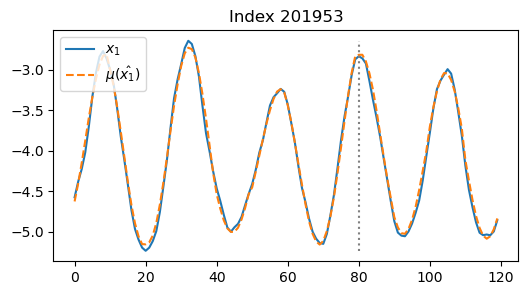

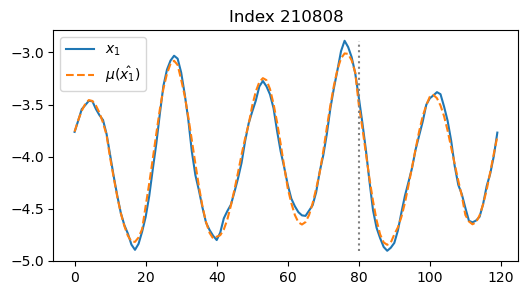

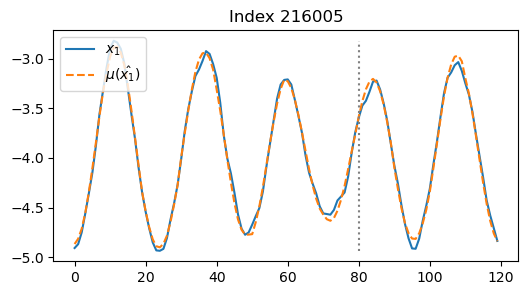

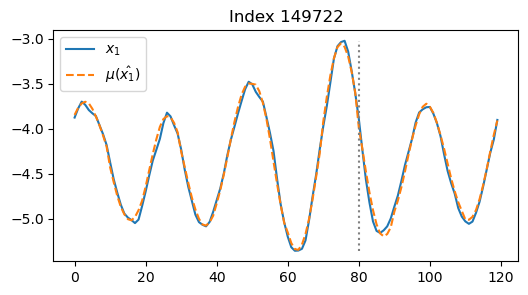

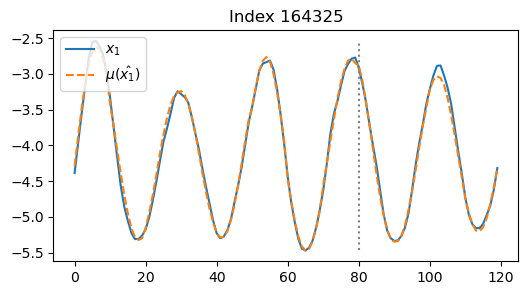

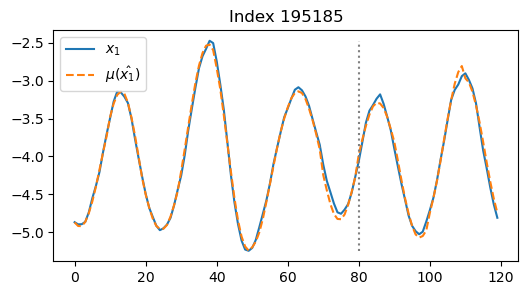

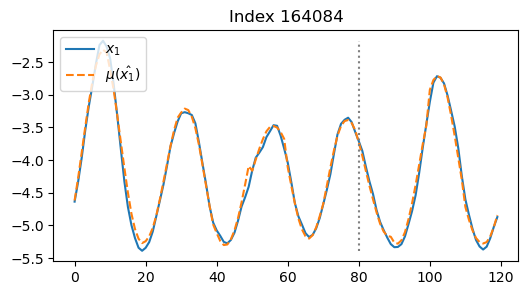

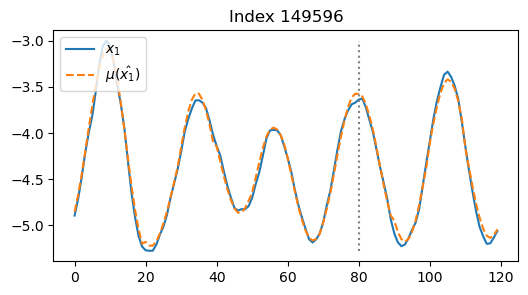

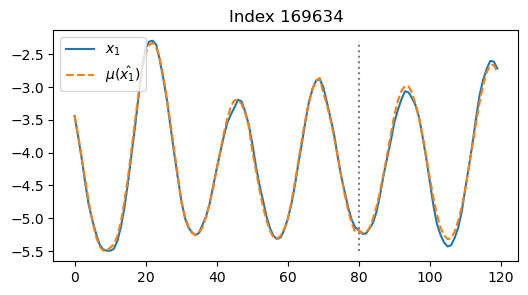

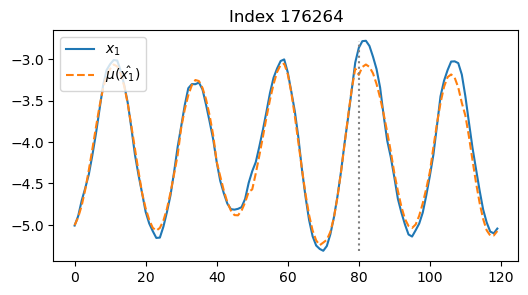

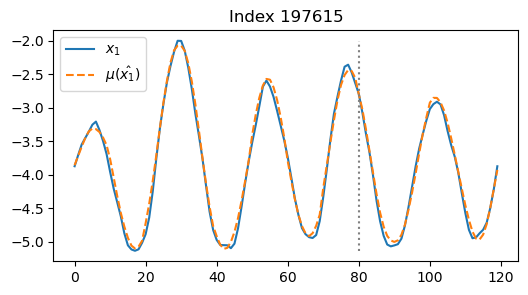

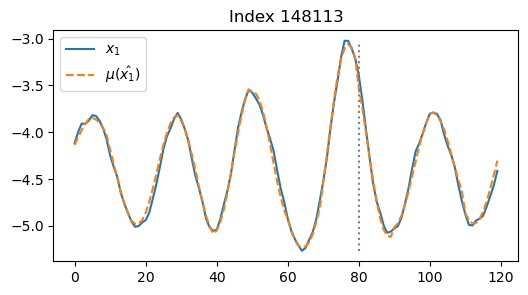

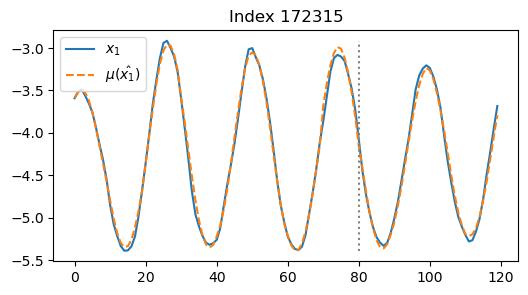

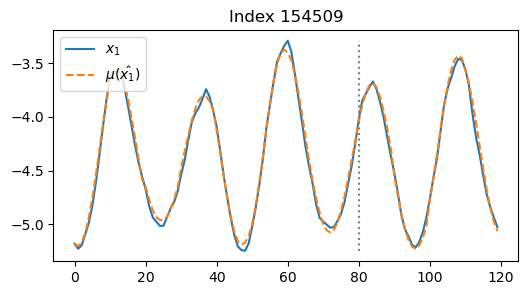

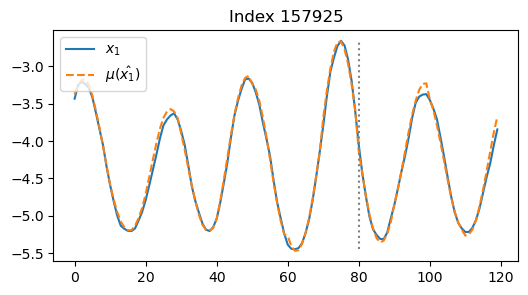

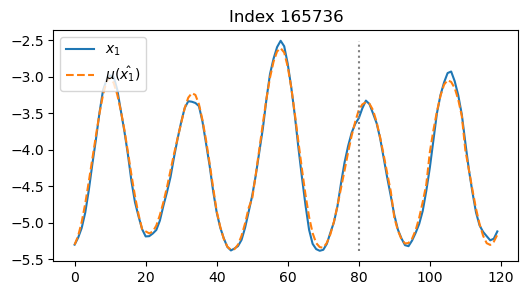

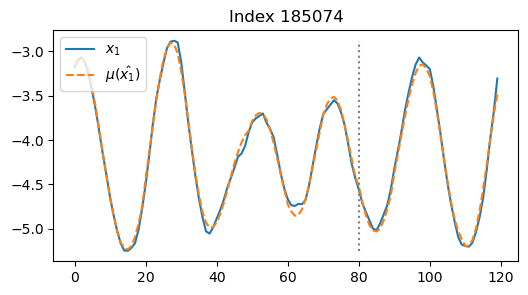

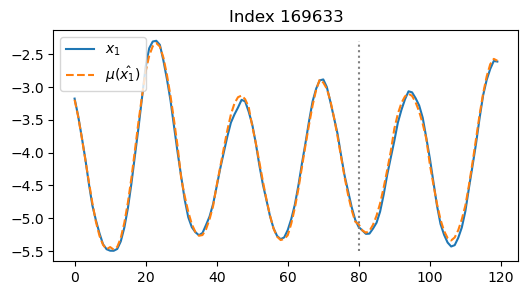

In [9]:
utils_plot.plot_mse_extreme2(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    k=50,
    jsave=159_585,
    datasaved=True, savedir='../../savedata/baselines/tesla')